# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?
2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?
3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?
4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?
5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

1. В чём принципиальная разница между методами SAX и SFA? Какой из них лучше справляется с зашумленными данными и почему?

SAX (Symbolic Aggregate approXimation) преобразует временной ряд в строку символов на основе аппроксимации кусочно-постоянными отрезками (PAA) и квантования значений. SFA (Symbolic Fourier Approximation) использует дискретное преобразование Фурье (ДПФ) для перехода в частотную область, а затем квантует коэффициенты. SFA лучше справляется с зашумленными данными, потому что ДПФ позволяет отфильтровать высокочастотные шумы, сохраняя основные частотные компоненты сигнала.

2. Как алгоритм BOSS (или WEASEL) использует концепцию TF-IDF для временных рядов?

BOSS и WEASEL строят «словарь» из подпоследовательностей временного ряда, закодированных с помощью SFA. Затем для каждого ряда формируется гистограмма встречаемости слов (bag-of-words). TF-IDF (term frequency – inverse document frequency) применяется к этим гистограммам: TF подчеркивает часто встречающиеся слова внутри одного ряда, а IDF уменьшает вес слов, которые часто встречаются во многих рядах (малоинформативных). Это позволяет выделить характерные локальные паттерны для каждого класса.

3. Что такое shapelet временного ряда? В чём преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?

Shapelet – это подпоследовательность временного ряда, которая наилучшим образом различает классы. Классический поиск шейплетов перебирает все возможные подпоследовательности всех рядов, что крайне вычислительно затратно. ROCKET генерирует случайные свертки (не обучаемые) с различными длинами ядер, весами и смещениями, а затем обучает простой линейный классификатор (ridge regression) на полученных признаках. Это позволяет получить сравнимую точность при огромном ускорении по сравнению с точным поиском шейплетов.

4. Модель catch22 извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?

Catch22 обеспечивает интерпретируемость, низкую вычислительную сложность и эффективность на малых выборках. CNN требуют больших объёмов данных для обучения и не дают простого объяснения, какие именно характеристики сигнала важны. Catch22 же даёт набор стандартизированных статистических признаков (например, автокорреляцию, энтропию, сезонность), что полезно в медицинских или финансовых задачах, где важна объяснимость.

5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

1D-CNN эффективны, потому что они автоматически извлекают локальные паттерны (пики, тренды, периодичности) с помощью свёрток вдоль временной оси, а пулинг уменьшает размерность и обеспечивает инвариантность к сдвигам. Многоветвевые преобразования (Inception Time) позволяют сети одновременно анализировать временные ряды на разных масштабах: короткие ветви улавливают быстрые колебания, длинные – глобальные тренды, что повышает точность на наборах с разнообразными паттернами.



# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


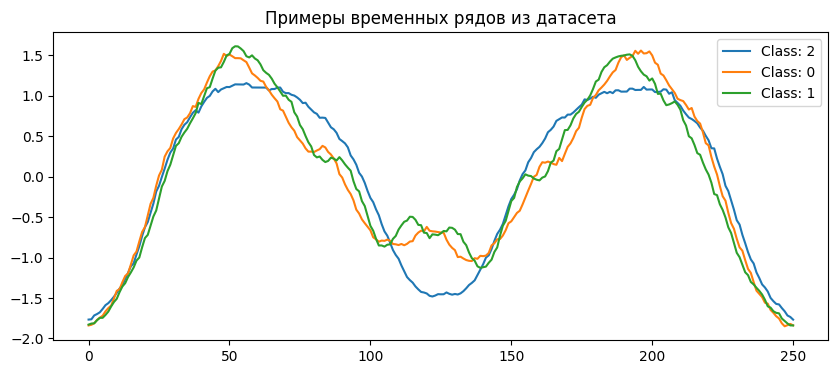

In [8]:
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [9]:
from sktime.classification.kernel_based import RocketClassifier
import time
from sklearn.metrics import accuracy_score

rocket = RocketClassifier(num_kernels=5000, random_state=42)
start = time.time()
rocket.fit(X_train, y_train)
train_time_rocket = time.time() - start

y_pred_rocket = rocket.predict(X_test)
acc_rocket = accuracy_score(y_test, y_pred_rocket)

print(f"ROCKET accuracy: {acc_rocket:.4f}")
print(f"ROCKET training time: {train_time_rocket:.2f} sec")

ROCKET accuracy: 0.9219
ROCKET training time: 10.68 sec


### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [10]:
from sktime.classification.dictionary_based import ContractableBOSS

boss = ContractableBOSS(n_parameter_samples=25, time_limit_in_minutes=2, random_state=42)
start = time.time()
boss.fit(X_train, y_train)
train_time_boss = time.time() - start

y_pred_boss = boss.predict(X_test)
acc_boss = accuracy_score(y_test, y_pred_boss)

print(f"cBOSS accuracy: {acc_boss:.4f}")
print(f"cBOSS training time: {train_time_boss:.2f} sec")

cBOSS accuracy: 0.9531
cBOSS training time: 14.56 sec


### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

Epoch 10/30, Loss: 0.4188
Epoch 20/30, Loss: 0.2140
Epoch 30/30, Loss: 0.1634
1D-CNN accuracy: 0.8438
1D-CNN training time: 2.00 sec


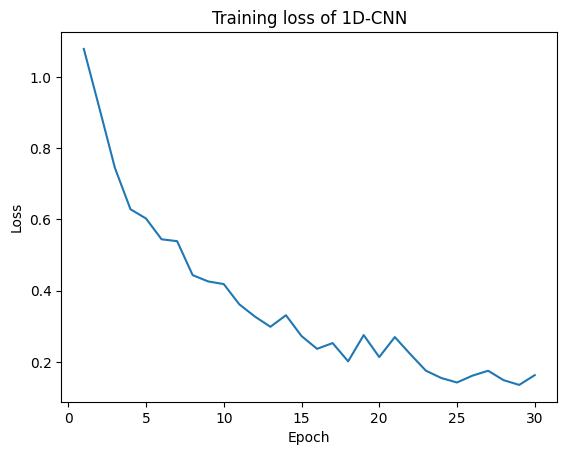

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

X_train_t = torch.tensor(X_train.astype(np.float32))
X_test_t = torch.tensor(X_test.astype(np.float32))
y_train_t = torch.tensor(y_train.astype(np.int64))
y_test_t = torch.tensor(y_test.astype(np.int64))

batch_size = 16
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Simple1DCNN(num_classes=len(np.unique(y_train))).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30
train_losses = []
model.train()
start = time.time()
for epoch in range(epochs):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

train_time_cnn = time.time() - start

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
acc_cnn = correct / total

print(f"1D-CNN accuracy: {acc_cnn:.4f}")
print(f"1D-CNN training time: {train_time_cnn:.2f} sec")

plt.plot(range(1, epochs+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss of 1D-CNN")
plt.show()

In [13]:
results = {
    "ROCKET": (acc_rocket, train_time_rocket),
    "cBOSS": (acc_boss, train_time_boss),
    "1D-CNN": (acc_cnn, train_time_cnn)
}

print("Метод          | Accuracy | Time (sec)")
print("-"*40)
for name, (acc, t) in results.items():
    print(f"{name:<14} | {acc:.4f}   | {t:.2f}")

Метод          | Accuracy | Time (sec)
----------------------------------------
ROCKET         | 0.9219   | 10.68
cBOSS          | 0.9531   | 14.56
1D-CNN         | 0.8438   | 2.00
